# Twitter Sentiment Classification: Positive - Neutral - Negative

In [17]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('twitter_sentiment_train.csv')
df_test  = pd.read_csv('twitter_sentiment_test.csv') # NOTE: Change this to the true test
training = False


In [18]:
int_to_label = {2: 'Positive', 1: 'Neutral', 0: 'Negative'}

In [19]:
df_train.head(2)

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1


In [20]:
y_train=df_train.pop('label')
y_test=df_test.pop('label')

#### Preprocessing Pipeline

In [21]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/antreaslaos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/antreaslaos/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/antreaslaos/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [22]:
import re, string
from ekphrasis.classes.tokenizer import SocialTokenizer
tokenizer = SocialTokenizer(lowercase=False).tokenize
# Standard preprocessing from labs
# Use of ekphrasis tokenizer
def uncontract(text):
    text = re.sub(r"(\b)([Aa]re|[Cc]ould|[Dd]id|[Dd]oes|[Dd]o|[Hh]ad|[Hh]as|[Hh]ave|[Ii]s|[Mm]ight|[Mm]ust|[Ss]hould|[Ww]ere|[Ww]ould)n't", r"\1\2 not", text)
    text = re.sub(r"(\b)([Hh]e|[Ii]|[Ss]he|[Tt]hey|[Ww]e|[Ww]hat|[Ww]ho|[Yy]ou)'ll", r"\1\2 will", text)
    text = re.sub(r"(\b)([Tt]hey|[Ww]e|[Ww]hat|[Ww]ho|[Yy]ou)'re", r"\1\2 are", text)
    text = re.sub(r"(\b)([Ii]|[Ss]hould|[Tt]hey|[Ww]e|[Ww]hat|[Ww]ho|[Ww]ould|[Yy]ou)'ve", r"\1\2 have", text)

    text = re.sub(r"(\b)([Cc]a)n't", r"\1\2n not", text)
    text = re.sub(r"(\b)([Ii])'m", r"\1\2 am", text)
    text = re.sub(r"(\b)([Ll]et)'s", r"\1\2 us", text)
    text = re.sub(r"(\b)([Ii]t)'s", r"\1\2 is", text)
    text = re.sub(r"(\b)([Tt]here)'s", r"\1\2 is", text)
    text = re.sub(r"(\b)([Ww])on't", r"\1\2ill not", text)
    text = re.sub(r"(\b)([Ss])han't", r"\1\2hall not", text)
    text = re.sub(r"(\b)([Yy])(?:'all|a'll)", r"\1\2ou all", text)

    return text


def tokenize_text(text):
    tokens = tokenizer(text)

    return tokens


def lowercase_tokens(tokens):
    tokens = [t.lower() for t in tokens]

    return tokens


def remove_stopwords(tokens):
    stop_words = stopwords.words('english')

    tokens = [t for t in tokens if t not in stop_words]

    return tokens


def lemmatize(tokens):
    lemmatizer = WordNetLemmatizer()

    lemmatized = [lemmatizer.lemmatize(t) for t in tokens]

    return lemmatized
 
def preprocessing_text(text):
   text = uncontract(text)
   text = tokenize_text(text)
   text = lowercase_tokens(text)
   text = remove_stopwords(text)
   text = lemmatize(text)

   return text

/Users/antreaslaos/miniconda3/envs/nlp/lib/python3.12/site-packages/ekphrasis/classes/tokenizer.py:225: FutureWarning: Possible nested set at position 2190
  self.tok = re.compile(r"({})".format("|".join(pipeline)))


#### Feature Extraction

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Preprocess
clean_train_tweet_tokens=[tokenize_text(text) for text in df_train['text']]
clean_train_tweet_tokens=[lowercase_tokens(tokens) for tokens in clean_train_tweet_tokens]
clean_train_tweet_tokens=[remove_stopwords(tokens) for tokens in clean_train_tweet_tokens]
clean_train_tweet_tokens=[lemmatize(tokens) for tokens in clean_train_tweet_tokens]

clean_tweet_text_train = [' '.join(tokens) for tokens in clean_train_tweet_tokens]

# Train TF-IDF model on preprocessed training data
tfidf_vectorizer = TfidfVectorizer(
   ngram_range  = (1,2), # unigrams and bigrams
   max_features = 1000,
   lowercase    = False,
   tokenizer    = None,
   preprocessor = None,
   stop_words   = None,
   min_df       = 10,
   max_df       = 0.80
)
tfidf_vectorizer.fit_transform(clean_tweet_text_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 337360 stored elements and shape (45615, 1000)>

In [24]:
def get_tfidf_matrix(texts: list[str], vectorizer: TfidfVectorizer) -> dict:
    """
    Takes a text string and a fitted TfidfVectorizer,
    and returns a dictionary with all n-grams in the vectorizer's vocabulary as keys
    and their corresponding TF-IDF scores in the input text as values.
    """
    # Apply preprocessing to text
    texts=[tokenize_text(text) for text in texts]
    texts=[lowercase_tokens(text) for text in texts]
    texts=[remove_stopwords(text) for text in texts]
    texts=[lemmatize(text) for text in texts]

    texts = [' '.join(text) for text in texts]
    
    tfidf_matrix = vectorizer.transform(texts)

    return tfidf_matrix

In [25]:
from pathlib import Path
import joblib
from tqdm import tqdm
from feature_selection import *
from glove_features import load_glove_txt, build_glove_feature_frame

try:
    from gensim import downloader as gensim_api
except Exception:
    gensim_api = None

# Cache configuration and parameter signature
CACHE_VERSION = "v3"
CACHE_DIR = Path("artifacts") / "cache" / "feature_pipeline"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DATA_PATH = CACHE_DIR / "dataset_features.joblib"
CACHE_VECTORIZER_PATH = CACHE_DIR / "tfidf_vectorizer.joblib"
CACHE_META_PATH = CACHE_DIR / "metadata.joblib"

# Optional GloVe configuration
GLOVE_ENABLED = True
GLOVE_PATH = Path("artifacts") / "embeddings" / "glove.twitter.27B.100d.txt"
GLOVE_MODEL_NAME = "glove-twitter-25"
GLOVE_MAX_WORDS = None
GLOVE_PREFIX = "glove"
glove_file_exists = GLOVE_PATH.exists()
gensim_available = gensim_api is not None

current_cache_metadata = {
    "cache_version": CACHE_VERSION,
    "tfidf_params": tfidf_vectorizer.get_params(),
    "feature_functions": [
        "log_number_of_tokens",
        "polarity_score",
        "subjectivity_score",
        "exclamation_count",
        "hashtag_count",
        "count_question",
        "mention_count",
        "has_url",
        "vader_scores",
        "count_happy_emoticons",
        "count_sad_emoticons",
        "count_negation",
        "negation_ratio",
        "emoji_sentiment",
        "count_elongated_words",
        "avg_token_length",
        "pos_tag_counts",
        "count_positive_words",
        "count_negative_words",
        "count_profanity"
    ],
    "glove": {
        "enabled": GLOVE_ENABLED,
        "path": str(GLOVE_PATH),
        "file_exists": glove_file_exists,
        "model_name": GLOVE_MODEL_NAME,
        "gensim_available": gensim_available,
        "max_words": GLOVE_MAX_WORDS,
        "prefix": GLOVE_PREFIX
    },
    "train_rows": len(df_train),
    "test_rows": len(df_test)
}

def cache_matches_current_params() -> tuple[bool, str]:
    # Checks if current metadata matches the expected parameters
    required_files = [CACHE_DATA_PATH, CACHE_VECTORIZER_PATH, CACHE_META_PATH]
    if not all(path.exists() for path in required_files):
        return False, "Missing one or more cache files"

    try:
        saved_metadata = joblib.load(CACHE_META_PATH)
    except Exception as exc:
        return False, f"Could not read cache metadata: {exc}"

    if saved_metadata != current_cache_metadata:
        return False, "Cache metadata differs from current parameters"

    return True, "Cache metadata matches current parameters"

cache_ok, cache_reason = cache_matches_current_params()

if cache_ok:
    # Use cached features instead of running feature extraction procedure
    cached_data = joblib.load(CACHE_DATA_PATH)
    X_train = cached_data["X_train"]
    X_test = cached_data["X_test"]
    y_train = cached_data["y_train"]
    y_test = cached_data["y_test"]
    tfidf_vectorizer = joblib.load(CACHE_VECTORIZER_PATH)

    # Strict validation to avoid using corrupted or stale cache
    if len(X_train) != len(y_train) or len(X_test) != len(y_test):
        raise ValueError("Cached features and labels have inconsistent lengths")
    if "text" not in X_train.columns or "text" not in X_test.columns:
        raise ValueError("Cached datasets must contain the 'text' column")

    train_feature_cols = [c for c in X_train.columns if c != "text"]
    test_feature_cols = [c for c in X_test.columns if c != "text"]
    if train_feature_cols != test_feature_cols:
        raise ValueError("Feature columns differ between cached train and test sets")

    print(f"Loaded cached features. ({cache_reason})")
else:
    # Cache not found or incorrect, run feature extraction and cache results
    print(f"Cache miss: {cache_reason}. Rebuilding features...")

    X_train = df_train.copy()
    X_test = df_test.copy()

    # Custom features
    feature_functions = [
        log_number_of_tokens,
        polarity_score,
        subjectivity_score,
        exclamation_count,
        hashtag_count,
        count_question,
        mention_count,
        has_url,
        vader_scores,
        count_happy_emoticons,
        count_sad_emoticons,
        count_negation,
        negation_ratio,
        emoji_sentiment,
        count_elongated_words,
        avg_token_length,
        pos_tag_counts,
        count_positive_words,
        count_negative_words,
        count_profanity
    ]

    # Extract each feature for tweets
    for func in tqdm(feature_functions):
        results = X_train['text'].apply(lambda x: func(str(x))).tolist()
        temp_df = pd.DataFrame(results)

        temp_df.reset_index(drop=True, inplace=True)
        X_train.reset_index(drop=True, inplace=True)
        X_train = pd.concat([X_train, temp_df], axis=1)

        results = X_test['text'].apply(lambda x: func(str(x))).tolist()
        temp_df = pd.DataFrame(results)

        temp_df.reset_index(drop=True, inplace=True)
        X_test.reset_index(drop=True, inplace=True)
        X_test = pd.concat([X_test, temp_df], axis=1)

    # Append TF-IDF scores for each tweet
    tfidf_matrix = get_tfidf_matrix(X_train['text'], tfidf_vectorizer)
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=tfidf_vectorizer.get_feature_names_out()
    )
    X_train = pd.concat([X_train.reset_index(drop=True), tfidf_df], axis=1)

    tfidf_matrix = get_tfidf_matrix(X_test['text'], tfidf_vectorizer)
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=tfidf_vectorizer.get_feature_names_out()
    )
    X_test = pd.concat([X_test.reset_index(drop=True), tfidf_df], axis=1)

    # Append mean and max GloVe embeddings
    if GLOVE_ENABLED:
        glove_embeddings = None
        glove_dim = None

        # Check if GloVe embedding exist locally
        if glove_file_exists:
            print(f"Loading GloVe embeddings from file: {GLOVE_PATH}...")
            glove_embeddings, glove_dim = load_glove_txt(
                GLOVE_PATH,
                max_words=GLOVE_MAX_WORDS
            )
        # If not locally, download embeddings
        elif gensim_available:
            print(f"Local GloVe file not found. Loading '{GLOVE_MODEL_NAME}' via gensim downloader...")
            glove_embeddings = gensim_api.load(GLOVE_MODEL_NAME)
            glove_dim = glove_embeddings.vector_size
        else:
            print("Skipping GloVe features (no local file and gensim unavailable).")

        # Add embeddings
        if glove_embeddings is not None and glove_dim is not None:
            train_tokens = [preprocessing_text(str(text)) for text in tqdm(X_train["text"], desc="Tokenizing train for GloVe")]
            test_tokens = [preprocessing_text(str(text)) for text in tqdm(X_test["text"], desc="Tokenizing test for GloVe")]

            glove_train_df = build_glove_feature_frame(train_tokens, glove_embeddings, glove_dim, prefix=GLOVE_PREFIX)
            glove_test_df = build_glove_feature_frame(test_tokens, glove_embeddings, glove_dim, prefix=GLOVE_PREFIX)

            X_train = pd.concat([X_train.reset_index(drop=True), glove_train_df.reset_index(drop=True)], axis=1)
            X_test = pd.concat([X_test.reset_index(drop=True), glove_test_df.reset_index(drop=True)], axis=1)

            print(f"Added {glove_train_df.shape[1]} GloVe features (mean+max pooling, dim={glove_dim}).")
    else:
        print("Skipping GloVe features (disabled by config).")

    # Cache results
    cache_payload = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
    joblib.dump(cache_payload, CACHE_DATA_PATH, compress=3)
    joblib.dump(tfidf_vectorizer, CACHE_VECTORIZER_PATH, compress=3)
    joblib.dump(current_cache_metadata, CACHE_META_PATH, compress=3)

    print("Feature cache saved.")

Cache miss: Missing one or more cache files. Rebuilding features...


100%|██████████| 20/20 [07:03<00:00, 21.20s/it]


Local GloVe file not found. Loading 'glove-twitter-25' via gensim downloader...


Tokenizing test for GloVe: 100%|██████████| 12284/12284 [00:01<00:00, 6916.36it/s]


Added 50 GloVe features (mean+max pooling, dim=25).
Feature cache saved.


In [26]:
X_train.head(10)

,text,log_tokens,polarity,subjectivity,exclamation_count,hashtag_count,question_count,mention_count,has_url,vader_compound,...,glove_max_015,glove_max_016,glove_max_017,glove_max_018,glove_max_019,glove_max_020,glove_max_021,glove_max_022,glove_max_023,glove_max_024
0,"""QT @user In the original draft of the 7th boo...",3.135494,0.375000,0.750000,0,1,0,1,0,0.4588,...,0.62027,0.99860,1.04560,0.97728,1.14090,0.39206,0.67767,0.56409,1.51670,0.72533
1,"""Ben Smith / Smith (concussion) remains out of...",2.944439,0.000000,0.000000,0,2,0,0,0,0.0000,...,0.20813,1.39180,1.27550,0.87897,1.21720,0.82511,1.32420,1.36760,0.58196,1.11490
2,Sorry bout the stream last night I crashed out...,3.258097,0.000000,0.488889,0,0,0,0,0,0.4215,...,1.17980,0.95243,0.77092,0.50586,0.69158,1.35000,0.65879,1.26040,1.40060,1.26850
3,Chase Headley's RBI double in the 8th inning o...,3.258097,0.000000,0.050000,0,0,0,0,0,0.0000,...,0.57361,0.92733,0.45559,1.25820,1.19700,0.56438,1.30930,2.32960,0.61130,0.44809
4,@user Alciato: Bee will invest 150 million in ...,3.178054,0.000000,0.000000,0,0,0,1,0,0.0000,...,0.50926,0.77955,0.10636,1.23320,0.42701,0.44059,1.18940,0.54726,0.76329,0.82808
5,@user LIT MY MUM 'Kerry the louboutins I wonde...,3.135494,1.000000,0.500000,4,0,0,1,0,0.0000,...,1.14440,1.32680,0.44428,0.92345,1.21250,1.04500,0.85815,0.58741,1.20350,1.16140
6,"""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIA...",3.806662,0.357143,0.571429,0,0,0,0,0,0.5319,...,1.12400,1.29910,0.81923,0.81318,1.45230,0.75601,0.69859,1.49470,1.49840,1.36980
7,So disappointed in wwe summerslam! I want to s...,2.890372,-0.318750,0.475000,1,0,0,0,0,0.2261,...,0.56739,0.67783,0.53896,0.55061,0.76382,0.53483,0.79573,0.65679,1.20350,1.16140
8,"""This is the last Sunday w/o football .....,NF...",3.044522,0.000000,0.033333,0,0,0,0,0,0.0000,...,0.14517,0.77360,0.39186,0.18356,0.86967,0.39206,0.68736,1.26040,0.70784,0.86134
9,@user @user CENA & AJ sitting in a tree K-I-S-...,3.737670,0.000000,0.000000,0,0,0,2,0,0.0000,...,0.89538,0.81036,0.64587,0.48650,0.91663,0.85292,0.71914,0.94209,1.77830,1.07230


### Feature Selection

Text(0.5, 1.0, 'Top k by importance')

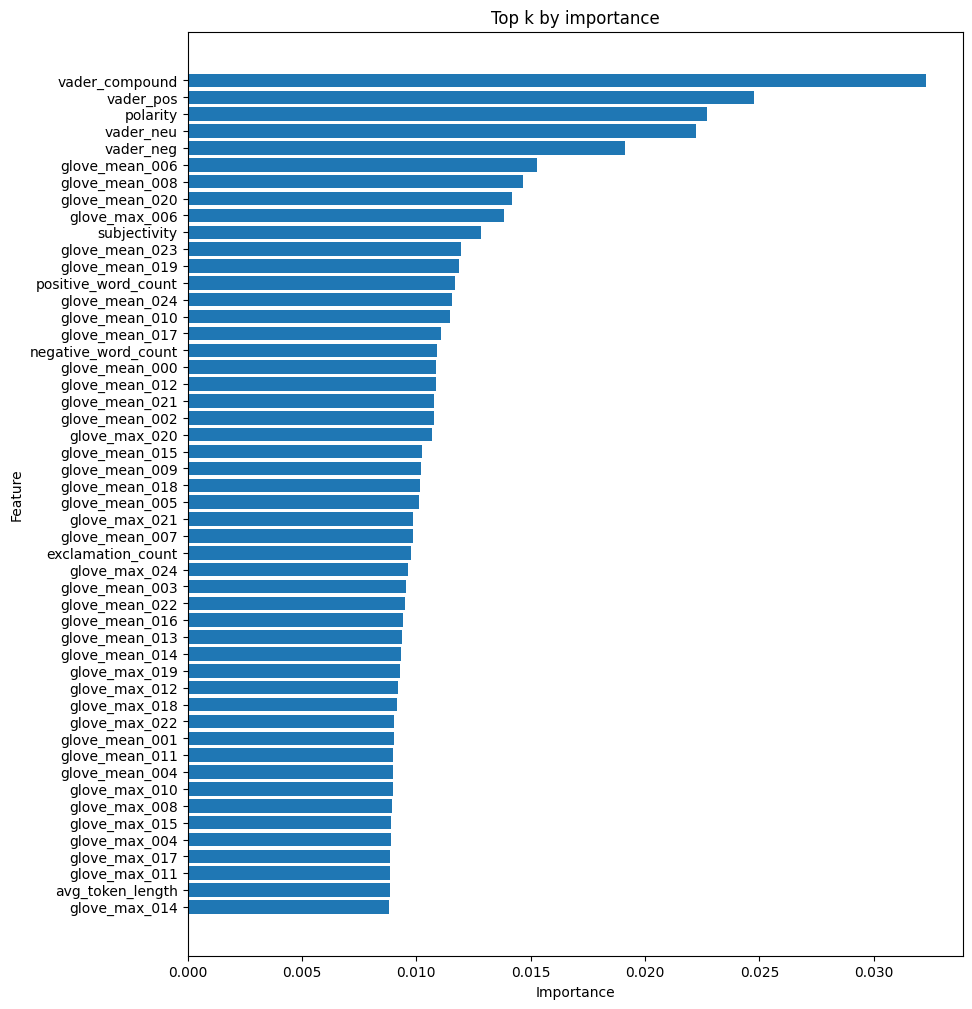

In [27]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
X_train_dropped = X_train.drop(columns=["text"])
X_test_dropped = X_test.drop(columns=["text"])

# Rank features on importance
model = RandomForestClassifier(n_estimators=100, random_state=123)
model.fit(X_train_dropped, y_train)

importances = model.feature_importances_

feature_importances = pd.DataFrame({
    'feature': X_train_dropped.columns,
    'importance': importances
})

sorted_feature_importances=feature_importances.sort_values(by="importance", ascending=False)

topk = sorted_feature_importances.head(50)['feature']

# Top k plot
plt.figure(figsize=(10, 12))
plt.barh(topk, sorted_feature_importances[sorted_feature_importances['feature'].isin(topk)]['importance'])
# Highest value at the top
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top k by importance")

#### Neural Network Training

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.callbacks import EarlyStopping

##### Optuna Hyperparameter Tuning

In [29]:
import optuna
from sklearn.model_selection import train_test_split
optuna.logging.set_verbosity(optuna.logging.WARNING)


if training: #set training to true to run optuna
    X_tr  = X_train_dropped[topk].values
    y_tr  = y_train.values

    X_val, X_test_final, y_val, y_test_final = train_test_split(
        X_test_dropped[topk].values, y_test, test_size=0.5, random_state=42, stratify=y_test
    )

    def objective(trial):
        n_layers     = trial.suggest_int("n_layers", 1, 3)
        units        = trial.suggest_categorical("units", [32, 64, 128, 256])
        activation   = trial.suggest_categorical("activation", ["relu", "gelu", "elu"])
        dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5, step=0.1)

        optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
        lr             = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)

        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

        # Build model
        tf.keras.backend.clear_session()
        model = Sequential()
        model.add(Dense(units, input_dim=X_tr.shape[1], activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

        for _ in range(n_layers - 1):
            model.add(Dense(units, activation=activation))
            if dropout_rate > 0:
                model.add(Dropout(dropout_rate))

        model.add(Dense(3, activation="softmax"))

        if optimizer_name == "adam":
            opt = Adam(learning_rate=lr)
        else:
            momentum = trial.suggest_float("momentum", 0.0, 0.9, step=0.1)
            opt = SGD(learning_rate=lr, momentum=momentum)

        model.compile(
            optimizer=opt,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=25,
            batch_size=batch_size,
            callbacks=[EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)],
            verbose=0
        )

        return max(history.history["val_accuracy"])


    study = optuna.create_study(direction="maximize", study_name="nn_topk_tuning")
    study.optimize(objective, n_trials=75, show_progress_bar=True)

    print("\nBest trial:")
    print(f"  Val accuracy : {study.best_value:.4f}")
    print(f"  Params       : {study.best_params}")



In [30]:
import pickle

# # Train model with identified best parameters
# best = {
#     'n_layers': 3,
#     'units': 64,
#     'activation': 'gelu',
#     'dropout_rate': 0.2,
#     'optimizer': 'adam',
#     'learning_rate': 0.0006123962416241381,
#     'batch_size': 32
# }
if training:
    best = study.best_params
    print("Best hyperparameters:", best)
    tf.keras.backend.clear_session()
    best_model = Sequential()
    best_model.add(Dense(best["units"], input_dim=X_tr.shape[1], activation=best["activation"]))
    if best["dropout_rate"] > 0:
        best_model.add(Dropout(best["dropout_rate"]))

    for _ in range(best["n_layers"] - 1):
        best_model.add(Dense(best["units"], activation=best["activation"]))
        if best["dropout_rate"] > 0:
            best_model.add(Dropout(best["dropout_rate"]))

    best_model.add(Dense(3, activation="softmax"))

    if best["optimizer"] == "adam":
        best_opt = Adam(learning_rate=best["learning_rate"])
    else:
        best_opt = SGD(learning_rate=best["learning_rate"], momentum=best.get("momentum", 0.0))

    best_model.compile(
        optimizer=best_opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    best_model.fit(
        X_tr, y_tr,
        epochs=25,
        batch_size=best["batch_size"],
        callbacks=[EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)],
        verbose=1
    )
else:
    X_test_final = X_test_dropped[topk].values
    y_test_final = y_test
    with open("best_nn_model.pkl", "rb") as f:
        best_model = pickle.load(f)


y_pred_best = np.argmax(best_model.predict(X_test_final), axis=1)
print("Tuned NN Accuracy:", accuracy_score(y_test_final, y_pred_best))
print(classification_report(y_test_final, y_pred_best, target_names=["Negative", "Neutral", "Positive"]))


384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step
Tuned NN Accuracy: 0.6572777596873982
              precision    recall  f1-score   support

    Negative       0.71      0.54      0.62      3972
     Neutral       0.63      0.79      0.70      5937
    Positive       0.70      0.50      0.58      2375

    accuracy                           0.66     12284
   macro avg       0.68      0.61      0.63     12284
weighted avg       0.67      0.66      0.65     12284



#### Evaluation

Confusion Matrix (rows=true, cols=pred):
[[2162 1707  103]
 [ 807 4717  413]
 [  76 1104 1195]]


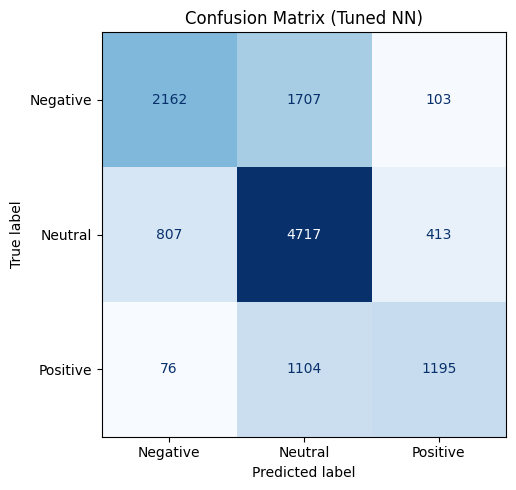

              precision    recall  f1-score   support

           0       0.71      0.54      0.62      3972
           1       0.63      0.79      0.70      5937
           2       0.70      0.50      0.58      2375

    accuracy                           0.66     12284
   macro avg       0.68      0.61      0.63     12284
weighted avg       0.67      0.66      0.65     12284



In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report



# Prefer tuned-model predictions when available; otherwise use the non-tuned predictions.
if 'y_test_final' in globals() and 'y_pred_best' in globals():
    y_true_cm = y_test_final
    y_pred_cm = y_pred_best
    cm_title = 'Confusion Matrix (Tuned NN)'
elif 'y_test' in globals() and 'y_pred_nn' in globals():
    y_true_cm = y_test
    y_pred_cm = y_pred_nn
    cm_title = 'Confusion Matrix (NN)'
else:
    raise ValueError('No compatible prediction variables found for confusion matrix.')

# Print confusion matrix
class_labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_true_cm, y_pred_cm, labels=[0, 1, 2])

print('Confusion Matrix (rows=true, cols=pred):')
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d'
)
ax.set_title(cm_title)
plt.tight_layout()
plt.show()

# Print classification report
print(classification_report(y_true_cm, y_pred_cm))

#### Save Model

In [32]:
import pickle
if training:
    with open("best_nn_model.pkl", "wb") as f:
        pickle.dump(best_model, f)